### import dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
cars = pd.read_csv('car data.csv')
cars.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


- checking the number of missing value

In [3]:
cars.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

- Information about cars dataframe

In [4]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


- checking the distribution of categorical data

In [5]:
cars.Fuel_Type.value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [6]:
cars.Selling_type.value_counts()

Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

In [7]:
cars.Transmission.value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

- Encoding the categorical data

In [8]:
cars.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}} , inplace=True)
cars.replace({'Selling_type':{'Dealer':0, 'Individual':1}} , inplace=True)
cars.replace({'Transmission':{'Manual':0, 'Automatic':1}} , inplace=True)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,0,0,0
297,brio,2015,4.00,5.90,60000,0,0,0,0
298,city,2009,3.35,11.00,87934,0,0,0,0
299,city,2017,11.50,12.50,9000,1,0,0,0


- Spliting the data and Target

In [9]:
X = cars.drop(['Car_Name' , 'Selling_Price'] , axis = 1)
y = cars['Selling_Price']

In [10]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42  
)

- Model Training

In [11]:
lr_model = LinearRegression()

In [12]:
# Linear Regression Model Training
lr_model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.36, 0.44,-0. ,...,-1.17, 1.64,-0.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Year','Present_Price','Driven_kms',...,'Selling_type','Transmission', 'Owner']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-728.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [13]:
# Model Evaluation
train_predictions = lr_model.predict(X_train)

In [14]:
error = metrics.r2_score(y_train , train_predictions)
print(f"R2 Score for Training Data: {error}")

R2 Score for Training Data: 0.8836563703329269


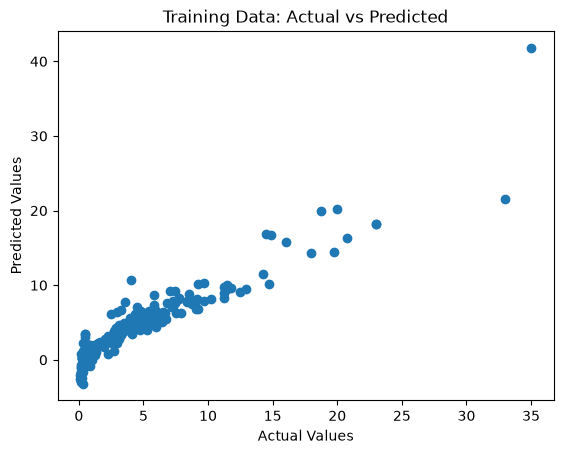

In [15]:
# Visualizing the predicted vs actual values for training data
plt.scatter(y_train, train_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Training Data: Actual vs Predicted")
plt.show()

In [16]:
# Prediction on Test Data
test_predictions = lr_model.predict(X_test)

In [17]:
error = metrics.r2_score(y_test , test_predictions)
print(f"R2 Score for Test Data: {error}")

R2 Score for Test Data: 0.8466902419660589


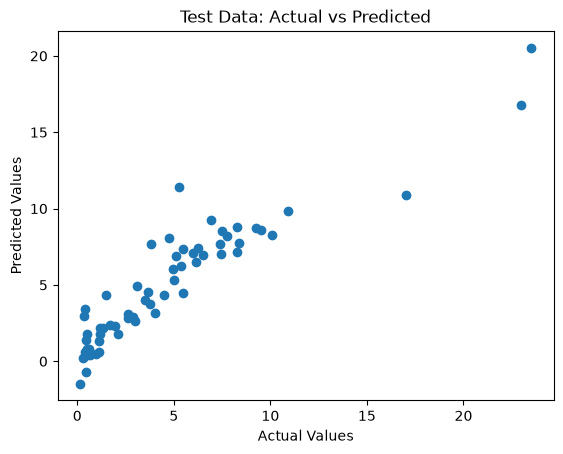

In [18]:
# Visualizing the predicted vs actual values for test data
plt.scatter(y_test , test_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Test Data: Actual vs Predicted")
plt.show()